# Extracting and Composing Robust Features with Denoising Autoencoders
**Authors:** Pascal Vincent, Hugo Larochelle, Yoshua Bengio, Pierre-Antoine Manzagol (Université de Montréal, ICML 2008)

# https://www.cs.toronto.edu/~larocheh/publications/icml-2008-denoising-autoencoders.pdf

## Abstract
This paper introduces a new unsupervised training principle for autoencoders, based on explicitly requiring learned representations to be robust to partial corruption of the input. The resulting **denoising autoencoder** is trained to reconstruct a clean input from a stochastically corrupted version of it, rather than simply reconstructing its own uncorrupted input as in a basic autoencoder. This criterion can be motivated from manifold learning, information-theoretic, and generative-model perspectives. Denoising autoencoders can be stacked to greedily initialize deep neural networks (forming Stacked Denoising Autoencoders, SdA-3). Comparative experiments on a benchmark suite of challenging MNIST-derived and shape classification tasks show that corrupting the input during autoencoder pre-training yields a significant and often surprising improvement in downstream supervised classification performance compared to using uncorrupted (basic) autoencoders, and generally matches or exceeds Deep Belief Networks and SVM baselines.

## Problems
- While unsupervised, layer-wise initialization (e.g., via RBMs or basic autoencoders) has been empirically shown to help train deep architectures and avoid poor local minima from random initialization, **little is understood about what explicit criteria constitute a "good" intermediate representation** for this purpose.
- The basic autoencoder objective (minimizing reconstruction error of the same input it is given) risks learning a trivial or uninteresting solution — most notably the identity mapping — particularly when the hidden layer is not constrained to be smaller than the input (no "bottleneck").
- Only a few algorithms (RBMs trained with contrastive divergence, and various autoencoder variants) were known to work well as unsupervised layer-wise initializers, without a clear guiding principle for representation quality beyond retaining input information (and, in some other work, sparsity).
- It was hypothesized, but not previously tested, that an additional explicit criterion — **robustness to partial destruction of the input** — could guide the learning of more useful intermediate representations, motivated by the human ability to recognize partially occluded/corrupted patterns and to recall multimodal concepts from incomplete modalities.

## Proposed Solutions
- Modify the standard autoencoder training objective to require reconstruction of the **clean, uncorrupted input** from a **stochastically corrupted version** of that input (rather than from the clean input itself), thereby explicitly enforcing the robustness-to-corruption criterion.
- Use a simple corruption process parameterized by a destruction fraction $\nu$: for each input, a randomly chosen fixed number $\nu d$ of components are set to 0 (masking noise), while the rest are left unchanged.
- Because the reconstruction target ($x$) differs from the network's input ($\tilde{x}$), the resulting **denoising autoencoder (DAE) cannot trivially learn the identity function**, removing the need for an under-complete (bottleneck) hidden layer or additional regularization to avoid this degenerate solution — permitting even over-complete hidden representations.
- Apply the same greedy layer-wise stacking and supervised fine-tuning procedure previously used for basic autoencoders (Bengio et al., 2007) to denoising autoencoders, forming deep networks (**SdA-3**, Stacked Denoising Autoencoders with 3 hidden layers), where the corruption process is used only during each layer's unsupervised training, not when propagating representations to higher layers.
- Provide multiple theoretical justifications for the criterion: a manifold learning interpretation (denoising as "projecting" corrupted points back onto a data manifold), a variational bound derivation showing the denoising training criterion is equivalent to maximizing a lower bound on the log-likelihood of a specific generative model, and an information-theoretic argument that minimizing reconstruction error is equivalent to maximizing a lower bound on mutual information $I(X;Y)$ between input and representation.

## Purpose
To test the hypothesis that explicitly enforcing robustness to partial input corruption is a useful and explicit criterion for learning "good" intermediate representations in unsupervised pre-training of deep architectures, and to empirically assess whether this denoising principle yields measurable improvements in downstream supervised classification performance compared to standard (non-denoising) autoencoder-based and RBM-based (DBN) pre-training.

## Methodology

### Basic Autoencoder (Baseline)
Given input $x \in [0,1]^d$, the encoder computes a hidden representation:
$$y = f_\theta(x) = s(Wx+b), \quad \theta=\{W,b\}$$
and the decoder reconstructs:
$$z = g_{\theta'}(y) = s(W'y+b'), \quad \theta'=\{W',b'\}$$
(optionally with tied weights $W'=W^T$). Parameters are optimized to minimize average reconstruction error:
$$\theta^\star,\theta'^\star = \arg\min_{\theta,\theta'} \frac{1}{n}\sum_{i=1}^n L\left(x^{(i)}, g_{\theta'}(f_\theta(x^{(i)}))\right) \quad (1)$$
using either squared error or reconstruction cross-entropy:
$$L_{\mathbb{H}}(x,z) = -\sum_{k=1}^d \big[x_k\log z_k + (1-x_k)\log(1-z_k)\big] \quad (2)$$

### Denoising Autoencoder
The input $x$ is first stochastically corrupted via $\tilde{x} \sim q_\mathcal{D}(\tilde{x}|x)$ (masking noise: a fixed number $\nu d$ of components randomly set to 0). The corrupted $\tilde{x}$ is encoded and decoded as before:
$$y = f_\theta(\tilde{x}) = s(W\tilde{x}+b), \qquad z = g_{\theta'}(y) = s(W'y+b')$$
but the training objective compares the reconstruction $z$ to the **original uncorrupted** $x$:
$$\arg\min_{\theta,\theta'} \mathbb{E}_{q^0(X,\tilde{X})}\left[L_{\mathbb{H}}\left(X, g_{\theta'}(f_\theta(\tilde{X}))\right)\right] \quad (5)$$
where $q^0(X,\tilde{X},Y) = q^0(X)q_\mathcal{D}(\tilde{X}|X)\delta_{f_\theta(\tilde{X})}(Y)$. Optimization is performed via stochastic gradient descent, where each training step additionally samples a fresh corrupted version of the chosen input example.

### Theoretical Justifications
- **Manifold learning perspective:** corrupted examples lie farther from the data manifold than clean ones; the learned stochastic operator $p(X|\tilde{X})$ learns to map corrupted points back toward the manifold, with the intermediate representation $Y$ acting as a coordinate system for the manifold.
- **Generative model / variational bound perspective:** defining a generative model $p(X,\tilde{X},Y) = p(Y)p(X|Y)p(\tilde{X}|X)$ with uniform prior $p(Y)$, the paper proves that the denoising training criterion (Eq. 5) is derived as maximizing a variational lower bound on the log-likelihood $\log p(\tilde{X})$ of corrupted samples under this model.
- **Information-theoretic perspective:** minimizing expected reconstruction error is shown (citing a companion technical report) to be equivalent to maximizing a lower bound on the mutual information $I(X;Y)$ between the input and its (corrupted-input-derived) representation.

### Layer-wise Initialization and Fine-tuning
Following the greedy layer-wise procedure of Bengio et al. (2007), each layer $k$ is trained as a denoising autoencoder on the **uncorrupted** output representation of the previously trained layer $k-1$ (corruption is applied only within each layer's own local unsupervised training, not when propagating representations upward). After pre-training several layers, parameters initialize a deep supervised network, which is then fine-tuned with a supervised criterion.

### Experimental Setup
- **Benchmark:** the ICML 2007 benchmark suite of Larochelle et al. (2007), comprising MNIST-derived variants — basic (784-dim MNIST subset), rot (rotated digits), bg-rand (random-pixel background), bg-img (image-patch background), rot-bg-img (combination) — plus binary shape classification tasks: convex vs. non-convex (convex), and wide vs. long rectangles (rect, rect-img). Each task uses 10,000 training / 2,000 validation / 50,000 test examples.
- **Model:** 3-hidden-layer neural networks initialized by stacking denoising autoencoders (**SdA-3**), then fine-tuned on the supervised classification task.
- **Model selection:** hyperparameters (destruction fraction $\nu$, layer sizes, number of unsupervised training epochs) selected via validation-set performance, combined with early stopping during fine-tuning, following the same procedure as Larochelle et al. (2007).
- **Baselines:** SVM with RBF kernel ($\text{SVM}_{rbf}$) and polynomial kernel ($\text{SVM}_{poly}$), 1-hidden-layer Deep Belief Network (DBN-1), 3-hidden-layer Deep Belief Network (DBN-3), and 3-hidden-layer stacked basic autoencoders (SAA-3, equivalent to SdA-3 with $\nu=0\%$).
- **Evaluation metric:** test-set classification error rate, reported with 95% confidence intervals.

## Results

| Dataset | $\text{SVM}_{rbf}$ | $\text{SVM}_{poly}$ | DBN-1 | SAA-3 | DBN-3 | SdA-3 ($\nu$) |
|---|---|---|---|---|---|---|
| basic | 3.03±0.15 | 3.69±0.17 | 3.94±0.17 | 3.46±0.16 | 3.11±0.15 | **2.80±0.14** (10%) |
| rot | 11.11±0.28 | 15.42±0.32 | 14.69±0.31 | 10.30±0.27 | 10.30±0.27 | **10.29±0.27** (10%) |
| bg-rand | 14.58±0.31 | 16.62±0.33 | 9.80±0.26 | 11.28±0.28 | **6.73±0.22** | 10.38±0.27 (40%) |
| bg-img | 22.61±0.37 | 24.01±0.37 | **16.15±0.32** | 23.00±0.37 | **16.31±0.32** | **16.68±0.33** (25%) |
| rot-bg-img | 55.18±0.44 | 56.41±0.43 | 52.21±0.44 | 51.93±0.44 | 47.39±0.44 | **44.49±0.44** (25%) |
| rect | **2.15±0.13** | **2.15±0.13** | 4.71±0.19 | 2.41±0.13 | 2.60±0.14 | **1.99±0.12** (10%) |
| rect-img | 24.04±0.37 | 24.05±0.37 | 23.69±0.37 | 24.05±0.37 | 22.50±0.37 | **21.59±0.36** (25%) |
| convex | 19.13±0.34 | 19.82±0.35 | 19.92±0.35 | 18.41±0.34 | 18.63±0.34 | 19.06±0.34 (10%) |

- SdA-3 achieves the best or statistically equivalent-to-best performance on **all tasks except bg-rand**, where DBN-3 performs notably better (6.73% vs. 10.38%).
- On several tasks (basic, rot-bg-img, rect, rect-img), SdA-3 achieves the single best test error among all evaluated models, including both DBN variants and both SVM kernels.
- SdA-3 consistently and often substantially outperforms SAA-3 (its non-denoising, $\nu=0\%$ counterpart) across nearly all tasks (e.g., rot-bg-img: 44.49% vs. 51.93%; rect-img: 21.59% vs. 24.05%; basic: 2.80% vs. 3.46%), directly demonstrating the benefit of the denoising criterion over standard autoencoder pre-training.
- Model selection consistently favored **over-complete** first-hidden-layer representations (typically 2000 units for 784-dimensional inputs) — a configuration infeasible for basic (non-denoising) autoencoders without risking a trivial identity-mapping solution, but made viable by the denoising criterion.
- Qualitative filter analysis (Figure 3) shows that first-layer filters learned with no corruption ($\nu=0\%$) are largely uninteresting, unstructured, near-uniform grey patches resembling random initialization; as the destruction level $\nu$ increases, filters increasingly resemble meaningful feature detectors (local blob detectors, stroke detectors, and even full character detectors at higher noise levels), with higher noise levels inducing less local, more spatially distributed filters.

## Conclusions
- Explicitly training autoencoders to be robust to partial input corruption — the denoising autoencoder principle — is empirically validated as an effective explicit criterion for learning useful intermediate representations, producing representations that are demonstrably better suited to downstream supervised classification tasks than those learned by basic (non-denoising) autoencoders.
- The corruption+denoising training removes the theoretical need for an under-complete bottleneck architecture to avoid learning a trivial identity mapping, enabling effective use of over-complete hidden representations, which model selection favored in most experiments.
- Stacked denoising autoencoders (SdA-3) perform on par with or better than Deep Belief Networks (RBM-initialized) on nearly all benchmark tasks, and substantially outperform SVM baselines and non-denoising stacked autoencoders (SAA-3) on most tasks, establishing denoising as a competitive and often superior alternative to contrastive-divergence-based RBM pre-training.
- The authors speculate that part of the strong empirical performance previously observed for Deep Belief Networks may be attributable to RBMs implicitly encoding a similar robustness-to-corruption property, owing to the stochastic (sampling-based) nature of their training, which introduces representation-level noise analogous to the explicit corruption used here.
- The paper's theoretical analysis — connecting the denoising training criterion to manifold learning, a variational lower bound on a specific generative model's log-likelihood, and a lower bound on input-representation mutual information — provides multiple convergent justifications for why this simple training modification is effective, beyond the purely empirical classification results.
- The authors propose as future work extending the corruption principle beyond simple input masking noise, potentially applying stochastic corruption not only to the raw input but recursively to intermediate hidden representations themselves, inspired by the paper's speculation about RBMs' implicit robustness properties.

# Mathematical and Statistical Content Summary

## 1. Notation and Information-Theoretic Preliminaries
$$\mathbb{E}_{p(X)}[f(X)] = \int p(x)f(x)\,dx, \quad \mathbb{H}(X) = \mathbb{E}_{p(X)}[-\log p(X)]$$
$$\mathbb{H}(X|Y) = \mathbb{E}_{p(X,Y)}[-\log p(X|Y)], \quad \mathbb{D}_{KL}(p\|q) = \mathbb{E}_{p(X)}\left[\log\frac{p(X)}{q(X)}\right]$$
$$\mathbb{H}(p\|q) = \mathbb{E}_{p(X)}[-\log q(X)] = \mathbb{H}(p) + \mathbb{D}_{KL}(p\|q), \quad I(X;Y) = \mathbb{H}(X) - \mathbb{H}(X|Y)$$

**Explanation:** These define, respectively, expectation, Shannon entropy (average "surprise" of a distribution), conditional entropy (remaining uncertainty in $X$ given $Y$), Kullback-Leibler divergence (a measure of how one distribution differs from another), cross-entropy (which decomposes into entropy plus KL divergence), and mutual information (how much knowing $Y$ reduces uncertainty about $X$). These tools underpin every later theoretical justification for the denoising criterion — the cross-entropy loss, the variational bound, and the mutual-information argument all rest on these definitions.

## 2. Sigmoid and Bernoulli Notation
$$s(x) = \frac{1}{1+e^{-x}}, \qquad s(\mathbf{x}) = (s(x_1),\ldots,s(x_d))^T, \qquad \mathcal{B}_\mu(x)$$

**Explanation:** The sigmoid function squashes real values into $(0,1)$, applied element-wise to vectors; it is used as the nonlinearity in every encoder/decoder layer. $\mathcal{B}_\mu(x)$ denotes a Bernoulli distribution with mean $\mu$ — used because autoencoder outputs are interpreted as probabilities of binary (or bit-probability) input values.

## 3. Supervised Learning Setup (i.i.d. Sample Assumption)
$$D_n = \{(x^{(1)},t^{(1)}),\ldots,(x^{(n)},t^{(n)})\} \sim q(X,T) \text{ i.i.d.}$$

**Explanation:** Standard statistical learning assumption: the $n$ training pairs are independently drawn from a fixed but unknown joint distribution $q(X,T)$. This frames the paper's later objectives as expectations under this (or a related empirical) distribution.

## 4. Basic Autoencoder: Encoding and Decoding
$$y = f_\theta(x) = s(Wx+b), \qquad z = g_{\theta'}(y) = s(W'y+b')$$

**Explanation:** The encoder $f_\theta$ maps input $x \in [0,1]^d$ to a hidden ("latent") representation $y \in [0,1]^{d'}$ via a linear transform plus sigmoid; the decoder $g_{\theta'}$ maps $y$ back to a reconstruction $z$ in the input space the same way. If $W' = W^T$ (tied weights), the number of free parameters is halved. This is the base architecture the whole paper builds on and modifies.

## 5. Basic Autoencoder Training Objective
$$\theta^\star,\theta'^\star = \arg\min_{\theta,\theta'} \frac{1}{n}\sum_{i=1}^n L\big(x^{(i)}, g_{\theta'}(f_\theta(x^{(i)}))\big) \quad (1)$$

**Explanation:** Parameters are chosen to minimize average reconstruction error across the training set — the standard empirical risk minimization framework applied to unsupervised reconstruction. $L$ is a generic loss function (e.g., squared error), optimized via stochastic gradient descent in practice.

## 6. Reconstruction Cross-Entropy Loss
$$L_{\mathbb{H}}(x,z) = \mathbb{H}(\mathcal{B}_x\|\mathcal{B}_z) = -\sum_{k=1}^d\big[x_k\log z_k + (1-x_k)\log(1-z_k)\big] \quad (2)$$

**Explanation:** Treating each input dimension as a Bernoulli variable, this is the cross-entropy between the "true" distribution $\mathcal{B}_x$ and the "predicted" distribution $\mathcal{B}_z$ — equivalently, the negative log-likelihood of $x$ under Bernoulli parameters $z$. This is the specific loss function used throughout the paper's experiments (rather than squared error), because inputs are treated as bit probabilities.

## 7. Basic Autoencoder Objective via Empirical Distribution
$$\theta^\star,\theta'^\star = \arg\min_{\theta,\theta'} \mathbb{E}_{q^0(X)}\big[L_{\mathbb{H}}(X,g_{\theta'}(f_\theta(X)))\big] \quad (3)$$

**Explanation:** Rewrites Eq. (1) as an expectation under the empirical distribution $q^0(X)$ of the $n$ training points (each with probability mass $1/n$) rather than as an explicit average — a formalization that becomes essential for the later variational-bound derivation, which manipulates expectations over $q^0$.

## 8. Stochastic Corruption Process
$$\tilde{x} \sim q_\mathcal{D}(\tilde{x}|x)$$

**Explanation:** Defines the core new ingredient of the paper: a stochastic mapping that corrupts a clean input $x$ into a partially destroyed version $\tilde{x}$. The specific process used sets a fixed number $\nu d$ of randomly chosen components to zero (masking noise), parameterized by destruction proportion $\nu \in [0,1]$. This stochastic corruption is what forces the autoencoder to learn to "fill in the blanks" rather than trivially copy its input.

## 9. Denoising Autoencoder Encoding/Decoding
$$y = f_\theta(\tilde{x}) = s(W\tilde{x}+b), \qquad z = g_{\theta'}(y) = s(W'y+b')$$

**Explanation:** Structurally identical to the basic autoencoder's equations, but crucially the encoder now receives the **corrupted** input $\tilde{x}$ rather than the clean $x$. The reconstruction $z$ is thus a function of the corrupted input, while training will still compare $z$ against the clean $x$.

## 10. Joint Distribution for the Auxiliary (Training-Time) Model
$$q^0(X,\tilde{X},Y) = q^0(X)\,q_\mathcal{D}(\tilde{X}|X)\,\delta_{f_\theta(\tilde{X})}(Y) \quad (4)$$

**Explanation:** Defines the full probabilistic picture of the training procedure as a chain: sample a clean input from the data ($q^0(X)$), corrupt it ($q_\mathcal{D}(\tilde{X}|X)$), then deterministically encode it into a representation ($Y = f_\theta(\tilde{X})$, expressed via a Dirac delta $\delta$ putting all probability mass on the deterministic output). This distribution is the "epistemic" model of the whole training pipeline, later reused in the variational bound derivation.

## 11. Denoising Autoencoder Training Objective
$$\arg\min_{\theta,\theta'} \mathbb{E}_{q^0(X,\tilde{X})}\big[L_{\mathbb{H}}(X, g_{\theta'}(f_\theta(\tilde{X})))\big] \quad (5)$$

**Explanation:** The central training criterion of the paper: minimize the expected reconstruction cross-entropy between the **clean** input $X$ and the reconstruction obtained by encoding-decoding the **corrupted** input $\tilde{X}$. This single equation is the mathematical definition of "denoising autoencoder training," implemented in practice by, at each SGD step, sampling both a training example and an independent corruption of it.

## 12. Manifold-Learning Interpretation (Stochastic Operator)
$$p(X|\tilde{X}) = \mathcal{B}_{g_{\theta'}(f_\theta(\tilde{X}))}(X)$$

**Explanation:** Interprets the trained model as defining a stochastic operator that maps a (possibly off-manifold) corrupted point $\tilde{X}$ back toward a distribution concentrated near the data manifold — i.e., a learned "denoising" conditional distribution. This underlies Figure 2's geometric picture: corrupted points lie farther from the manifold, and the model learns to project them back.

## 13. Generative Model for the Variational Analysis
$$p(X,\tilde{X},Y) = p(Y)\,p(X|Y)\,p(\tilde{X}|X), \quad p(X|Y)=\mathcal{B}_{s(W'Y+b')}, \quad p(\tilde{X}|X)=q_\mathcal{D}(\tilde{X}|X), \quad p(Y)\sim \text{Unif}([0,1]^{d'})$$

**Explanation:** Defines a top-down generative story — matching the denoising autoencoder's parameters — used purely as a theoretical device: a latent code $Y$ is drawn uniformly, generates a clean $X$ via the decoder, which is then corrupted into $\tilde{X}$. This is the model whose likelihood the paper shows the denoising training criterion is implicitly maximizing (a lower bound on it).

## 14. Maximum Likelihood on Corrupted Data (Fitting Objective)
$$\mathcal{H} = \max_{\theta'}\{-\mathbb{H}(q^0(\tilde{X})\|p(\tilde{X}))\} = \max_{\theta'}\{\mathbb{E}_{q^0(\tilde{X})}[\log p(\tilde{X})]\} \quad (6)$$

**Explanation:** Casts standard maximum-likelihood fitting (of the generative model to observed *corrupted* training samples) as equivalently minimizing cross-entropy between the empirical distribution of corrupted data and the model's distribution over corrupted data — a standard statistical identity (MLE = cross-entropy minimization) applied here to justify treating $p(\tilde X)$ as the quantity to fit.

## 15. Variational Lower Bound on Log-Likelihood
$$\mathcal{L}(q^\star,\tilde{X}) = \mathbb{E}_{q^\star(X,Y|\tilde{X})}\left[\log\frac{p(X,\tilde{X},Y)}{q^\star(X,Y|\tilde{X})}\right]$$
$$\log p(\tilde{X}) = \mathcal{L}(q^\star,\tilde{X}) + \mathbb{D}_{KL}(q^\star(X,Y|\tilde{X})\|p(X,Y|\tilde{X}))$$

**Explanation:** A standard variational inference identity: for any auxiliary conditional distribution $q^\star$, the true log-likelihood decomposes exactly into a lower bound $\mathcal{L}$ plus a non-negative KL "gap" term. Since KL divergence is always $\geq 0$, $\mathcal{L}(q^\star,\tilde X)$ is guaranteed to be a lower bound on $\log p(\tilde X)$, with equality when $q^\star$ exactly matches the true posterior $p(X,Y|\tilde X)$. This identity is the mathematical engine used to connect the (tractable) denoising training objective to the (intractable) generative log-likelihood.

## 16. Tightness Condition and Bound Rewriting
$$\log p(\tilde{X}) = \max_{q^\star}\mathcal{L}(q^\star,\tilde{X})$$
$$\mathcal{H} = \max_{\theta',q^\star}\{\mathbb{E}_{q^0(\tilde{X})}[\mathcal{L}(q^\star,\tilde{X})]\} \quad (7)$$

**Explanation:** Since the bound in item 15 is tight (equals the true log-likelihood) precisely when $q^\star$ matches the true posterior, taking the maximum over $q^\star$ recovers the exact log-likelihood. Substituting this into Eq. (6) reframes the maximum-likelihood objective as a joint maximization over both the generative parameters $\theta'$ and the auxiliary distribution $q^\star$ — setting up the derivation for restricting $q^\star$ to a tractable, parameterized family.

## 17. Restricting $q^\star$ to the Denoising Autoencoder's Encoder
$$\mathcal{H} \geq \max_{\theta',\theta}\{\mathbb{E}_{q^0(\tilde{X})}[\mathcal{L}(q^0,\tilde{X})]\}$$

**Explanation:** Rather than optimizing over all possible (unconstrained) conditional distributions $q^\star$, the bound is further loosened by restricting attention to the specific parametric family $q^0(X,Y|\tilde X)$ defined by the encoder $f_\theta$ (Eq. 4) — a strictly poorer, but tractable, choice. This substitution is what ultimately connects the abstract variational framework to the concrete, learnable denoising autoencoder.

## 18. Derivation Reducing the Bound to the Denoising Training Criterion
$$\arg\max_{\theta,\theta'}\mathbb{E}_{q^0(\tilde{X})}[\mathcal{L}(q^0,\tilde{X})] = \arg\max_{\theta,\theta'}\mathbb{E}_{q^0(X,\tilde{X},Y)}[\log p(X,\tilde{X},Y)]$$
$$= \arg\max_{\theta,\theta'}\mathbb{E}_{q^0(X,\tilde{X})}[\log p(X|Y=f_\theta(\tilde{X}))] = \arg\min_{\theta,\theta'}\mathbb{E}_{q^0(X,\tilde{X})}\big[L_{\mathbb{H}}(X,g_{\theta'}(f_\theta(\tilde{X})))\big]$$

**Explanation:** A multi-step algebraic derivation (using the fact that the entropy of $q^0(X,Y|\tilde X)$ does not depend on $(\theta,\theta')$, and that $p(Y)$ was chosen uniform/constant) shows that maximizing this restricted variational bound is **exactly equivalent** to minimizing the denoising reconstruction cross-entropy objective of Eq. (5). This is the paper's key theoretical result: it proves that training a denoising autoencoder by gradient descent on reconstruction cross-entropy is mathematically equivalent to performing approximate (variational) maximum-likelihood estimation in a specific latent-variable generative model of corrupted data.

## 19. Information-Theoretic (Mutual Information) Justification
$$X \sim q(X), \quad Y = f_\theta(\tilde{X})$$

**Explanation:** The paper states (citing a companion technical report for the full proof) that minimizing the expected reconstruction error is equivalent to **maximizing a lower bound on the mutual information** $I(X;Y)$ between the original input and the representation derived from its corrupted version. This gives a third, independent theoretical motivation: denoising training is implicitly forcing the learned code $Y$ to retain as much information as possible about the clean $X$, despite being computed only from a corrupted view of it.

## 20. Stochastic Operator / Semi-Parametric Sampling Model
$$p(X) = \frac{1}{n}\sum_{i=1}^n \sum_{\tilde{x}} p(X|\tilde{X}=\tilde{x})\,q_\mathcal{D}(\tilde{x}|x_i)$$

**Explanation:** Describes how, after training, one could in principle define a generative sampling procedure over the *original* data distribution: pick a training example, corrupt it stochastically, then decode it via the learned $p(X|\tilde X)$. This frames the trained denoising autoencoder as an implicit generative (semi-parametric, mixture-like) model over the input space, connecting back to the manifold-learning interpretation.

## 21. Layer-wise Greedy Composition (Notation)
**Explanation:** Formalized as: the representation output by layer $k$ (trained via Eq. 5, using corruption only during that layer's own training) becomes the **uncorrupted** input to layer $k+1$'s training. This recursive, layer-by-layer application of the same statistical training criterion is what allows the method to build deep (here, 3-hidden-layer, "SdA-3") architectures.

## 22. Experimental Evaluation Statistics
**Explanation:** Test set classification error rates are reported for each of 8 benchmark datasets together with **95% confidence intervals**, computed for a fixed test-set size (50,000 examples per task) — the standard statistical device for judging whether an observed difference in error rate between two models is likely to reflect a real performance difference versus sampling noise; the paper explicitly bolds all models whose confidence intervals overlap with the best performer, treating them as statistically indistinguishable rather than declaring a single unique winner.

## 23. Destruction Fraction as a Model Hyperparameter
$$\nu \in \{0\%, 10\%, 25\%, 40\%, \ldots\}$$

**Explanation:** $\nu$, the fraction of input components destroyed per corruption, is treated as a hyperparameter selected via validation-set performance (grid search + early stopping), alongside layer sizes and number of unsupervised training epochs — standard statistical model-selection practice. The paper notes SAA-3 (basic autoencoder stacking) is mathematically the special case $\nu = 0\%$ of SdA-3, situating the entire baseline comparison as one point on the same hyperparameter axis being tuned for the denoising model.

## Summary Table of Key Mathematical/Statistical Elements

| Concept | Type | Role in Paper |
|---|---|---|
| Entropy, KL divergence, mutual information (item 1) | Information theory | Foundational tools for all theoretical justifications |
| Basic autoencoder equations + objective (items 4–7) | Deterministic model + empirical risk minimization | Baseline architecture being modified |
| Corruption process $q_\mathcal{D}(\tilde x|x)$ (item 8) | Stochastic process | Core novel ingredient of the method |
| Denoising training objective (Eq. 5, item 11) | Statistical learning objective | The paper's actual training criterion, used in all experiments |
| Manifold / stochastic operator interpretation (items 12, 20) | Geometric / generative interpretation | Intuitive justification |
| Generative model + variational bound (items 13–18) | Latent-variable model + variational inference | Rigorous proof that denoising training = approximate MLE |
| Mutual information bound (item 19) | Information-theoretic bound | Third independent theoretical justification |
| 95% confidence intervals (item 22) | Statistical significance testing | Used to compare all models in Table 1 |
| Destruction fraction $\nu$ (item 23) | Model hyperparameter | Selected via validation-based model selection |

## Overall Role of the Mathematics in the Paper
The mathematics serves to (1) precisely **define** the denoising training objective as a modification of the standard autoencoder reconstruction criterion (Eqs. 1–5), and (2) **rigorously justify** this simple modification from three independent, convergent theoretical angles — a geometric manifold-learning picture, a formal variational-inference proof that denoising training approximately maximizes the log-likelihood of a specific corrupted-data generative model, and an information-theoretic mutual-information bound — while (3) standard statistical evaluation practice (confidence intervals, validation-based model selection) is used to empirically confirm that this theoretically motivated criterion translates into a measurable, significant improvement in downstream classification performance across a benchmark of challenging vision tasks.

# Structured Review Table: Problems, Limitations, and Proposed Solutions

| # | Key Problem / Research Gap | How It Limits Prior Work | Proposed Solution in This Paper |
|---|---|---|---|
| 1 | Unsupervised, layer-wise initialization (via RBMs or basic autoencoders) has been shown empirically to help train deep architectures, but little is understood about what explicit criteria constitute a "good" intermediate representation for this purpose. | Without a guiding principle, practitioners rely on empirically successful but poorly understood algorithms (RBMs with contrastive divergence, basic autoencoders), limiting the ability to systematically improve or generalize the pre-training approach. | Proposes and empirically validates an explicit, testable criterion — robustness to partial destruction of the input — as a principled objective for learning useful intermediate representations, motivated by human robustness to occlusion/corruption and multimodal recall from incomplete evidence. |
| 2 | The basic autoencoder objective (reconstructing its own input) risks learning a trivial solution, most notably the identity mapping, especially when the hidden layer is not smaller than the input (no bottleneck). | This constrains architectural choices, forcing the use of under-complete (bottleneck) hidden layers or additional regularization (e.g., weight decay) to avoid the degenerate identity solution, which limits representational capacity and, per the paper, does not yield comparable performance gains. | Modifies the autoencoder to reconstruct the *clean* input from a *corrupted* version of it, so the reconstruction target differs from the network's input, making the identity mapping impossible to learn and removing the need for a bottleneck or specialized regularization. |
| 3 | Only a small number of algorithms (RBMs with contrastive divergence, various autoencoder variants) were known to work well for unsupervised layer-wise deep network initialization, with sparsity being the main previously proposed supplemental criterion. | The limited set of known effective criteria/algorithms restricts the design space for improving deep architecture pre-training and leaves open whether other explicit criteria could yield further gains. | Introduces and empirically tests a new, previously unexplored criterion — corruption robustness — as an alternative/complementary criterion to sparsity, broadening the known set of effective unsupervised pre-training principles. |
| 4 | It was hypothesized, but not previously tested, that explicit robustness to partial input corruption could guide learning of better intermediate representations; no prior formal training procedure operationalized this hypothesis for deep network initialization. | Without an operational algorithm and empirical validation, the corruption-robustness hypothesis remained speculative and could not be leveraged in practice for training deep architectures. | Operationalizes the hypothesis via a concrete, simple corruption process (masking a fixed random fraction $\nu$ of input components to zero) combined with a denoising reconstruction training objective (Eq. 5), and validates it experimentally on a benchmark of eight classification tasks. |
| 5 | The relationship between denoising-based training and formal probabilistic/statistical learning theory (e.g., maximum likelihood, information theory) was not established, leaving the approach without rigorous theoretical grounding beyond intuition. | Absent a formal justification, the method's effectiveness could appear ad hoc or difficult to generalize/extend with confidence to other settings or corruption types. | Provides three independent theoretical justifications: a manifold-learning interpretation (denoising as projecting corrupted points back onto the data manifold), a variational-bound proof that the denoising criterion approximately maximizes the log-likelihood of a specific generative model of corrupted data, and an information-theoretic argument that the criterion maximizes a lower bound on mutual information between input and representation. |
| 6 | It remained an open empirical question whether adding explicit input corruption during autoencoder pre-training would translate into measurable improvements on downstream supervised classification tasks, compared to standard (non-denoising) autoencoder stacking and RBM-based Deep Belief Networks. | Without controlled comparative experiments, it was unclear whether the theoretically motivated denoising criterion would yield practical benefits or whether existing methods (DBNs, basic stacked autoencoders, SVMs) were already sufficient. | Conducts systematic experiments on the ICML 2007 benchmark suite (MNIST variants and shape classification tasks), comparing 3-hidden-layer stacked denoising autoencoders (SdA-3) against SVMs, DBN-1, DBN-3, and non-denoising stacked autoencoders (SAA-3), using validation-based model selection and 95% confidence intervals, showing SdA-3 matches or exceeds all baselines on 7 of 8 tasks. |
| 7 | It was unclear whether the strong performance of Deep Belief Networks (RBM-initialized) in prior work stemmed from properties unique to RBMs, or from a more general robustness-inducing mechanism that could also be captured by other means. | Without investigating this question, the field lacked insight into why DBNs work well, potentially attributing their success entirely to RBM-specific properties rather than a more general and transferable principle. | Speculates, based on the observed effectiveness of explicit denoising, that RBMs' stochastic (sampling-based) training may implicitly encapsulate a similar robustness-to-corruption effect, proposing this as a direction for future investigation into other corruption processes applied to both inputs and intermediate representations. |
| 8 | There was no clear qualitative understanding of what internal features/filters unsupervised pre-training methods actually learn, or how a proposed corruption-based criterion changes the nature of these learned features compared to standard reconstruction training. | Lacking such qualitative analysis, claims of "better" or "more useful" representations were difficult to substantiate beyond downstream task accuracy, offering limited insight into the mechanism behind any observed improvements. | Performs a qualitative filter analysis (Figure 3), visualizing first-layer weight vectors as image patches across increasing destruction levels $\nu$, showing that denoising training produces increasingly distinctive, structured feature detectors (blob, stroke, and character detectors) compared to the largely uninteresting, near-uniform filters learned without corruption. |

In [1]:
# ============================================================================
# Educational Replication: "Extracting and Composing Robust Features with
# Denoising Autoencoders" (Vincent, Larochelle, Bengio & Manzagol, 2008, ICML)
#
# Core idea: instead of training an autoencoder to reconstruct its own
# (clean) input, corrupt the input (mask a random fraction nu of pixels to
# 0) and train the autoencoder to reconstruct the ORIGINAL clean input from
# the corrupted version (Eq. 5 in the paper). Stacking several such
# "denoising autoencoder" layers greedily (Section 2.4), then fine-tuning
# the whole network with a supervised classification criterion, forms the
# paper's SdA-3 model. We replicate this on CIFAR-10 via HuggingFace.
#
# Single-cell, educational PyTorch implementation.
# Do NOT execute automatically -- for manual run in Colab/Jupyter.
# ============================================================================

import io
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as T
from datasets import load_dataset
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display, Image as IPImage

In [2]:
# ----------------------------------------------------------------------------
# 0. GLOBAL WHITE-THEME SETTINGS (applied everywhere, per instructions)
# ----------------------------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "text.color": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.titlecolor": "black",
    "grid.color": "lightgrey",
    "legend.labelcolor": "black",
    "savefig.facecolor": "white",
})

torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CLASS_NAMES = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

In [ ]:
# ----------------------------------------------------------------------------
# 1. DATASET PREPARATION (HuggingFace CIFAR-10, mandatory)
# ----------------------------------------------------------------------------

ds = load_dataset("uoft-cs/cifar10")

train_transform = T.Compose([
    T.Resize((64, 64)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
test_transform = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class HFCIFAR10Dataset(Dataset):
    """Wraps a HuggingFace CIFAR-10 split into a standard PyTorch Dataset."""
    def __init__(self, hf_split, transform):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        sample = self.hf_split[idx]
        img = sample["img"]
        if img.mode != "RGB":
            img = img.convert("RGB")
        img_tensor = self.transform(img)
        label = sample["label"]
        return img_tensor, label

train_dataset_full = HFCIFAR10Dataset(ds["train"], train_transform)
test_dataset_full = HFCIFAR10Dataset(ds["test"], test_transform)

train_dataset = Subset(train_dataset_full, list(range(2000)))
test_dataset = Subset(test_dataset_full, list(range(400)))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

# Sanity check
sample_imgs, sample_labels = next(iter(train_loader))
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")
print(f"Shape of one batch of images: {sample_imgs.shape}")
print(f"Label range: {sample_labels.min().item()} to {sample_labels.max().item()}")
print(f"First 8 class names in batch: {[CLASS_NAMES[l] for l in sample_labels[:8].tolist()]}")

In [4]:
# ----------------------------------------------------------------------------
# 2. MODEL DEFINITION
#
# 3-hidden-layer network (SdA-3, Section 5), each layer a DENOISING
# autoencoder: y = s(W*x_tilde + b), z = s(W'*y + b'), trained to minimize
# reconstruction cross-entropy between z and the CLEAN x (Eq. 2, Eq. 5),
# where x_tilde is x with a random fraction nu of components masked to 0
# (Section 2.3). After pre-training all layers, a linear classifier head
# is added and the whole network is fine-tuned supervised (Section 2.4).
# ----------------------------------------------------------------------------

INPUT_DIM = 3 * 64 * 64
HIDDEN_DIMS = [256, 128, 64]  # 3 hidden layers, as in the paper's SdA-3
NUM_CLASSES = 10
NU = 0.25  # destruction fraction (paper explores 10-40%; 25% used here)

class DenoisingAutoEncoderLayer(nn.Module):
    """
    Single denoising-autoencoder building block (paper Section 2.3).
    Encoder/decoder use TIED weights (W' = W^T), as in the paper's default.
    """
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        self.W = nn.Parameter(torch.randn(hidden_dim, in_dim) * 0.01)
        self.b = nn.Parameter(torch.zeros(hidden_dim))    # hidden bias
        self.c = nn.Parameter(torch.zeros(in_dim))          # reconstruction bias

    def encode(self, x):
        return torch.sigmoid(x @ self.W.t() + self.b)       # y = s(Wx + b)

    def decode(self, h):
        return torch.sigmoid(h @ self.W + self.c)             # z = s(W'y + c), W'=W^T

    def forward(self, x_tilde):
        h = self.encode(x_tilde)
        z = self.decode(h)
        return h, z


def corrupt(x, nu):
    """
    Masking-noise corruption process q_D(x_tilde|x) from Section 2.3:
    for each example, a random fraction nu of components are set to 0.
    """
    mask = (torch.rand_like(x) > nu).float()  # 1 = keep, 0 = destroy
    return x * mask


class SdA3(nn.Module):
    """
    Full deep network assembled from greedily pre-trained DENOISING
    autoencoder layers, with a final linear classifier head for
    supervised fine-tuning (Section 2.4).
    """
    def __init__(self, input_dim, hidden_dims, num_classes):
        super().__init__()
        self.dae_layers = nn.ModuleList()
        prev_dim = input_dim
        for h_dim in hidden_dims:
            self.dae_layers.append(DenoisingAutoEncoderLayer(prev_dim, h_dim))
            prev_dim = h_dim
        self.classifier = nn.Linear(prev_dim, num_classes)

    def forward(self, x):
        h = x
        for layer in self.dae_layers:
            h = layer.encode(h)  # clean propagation at inference/fine-tune time
        logits = self.classifier(h)
        return logits

model = SdA3(INPUT_DIM, HIDDEN_DIMS, NUM_CLASSES).to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params}")

Total trainable parameters: 3200458


In [5]:
# ----------------------------------------------------------------------------
# 3. GREEDY LAYER-WISE DENOISING PRE-TRAINING
#
# Trains each denoising auto-encoder layer IN SEQUENCE. Corruption (masking
# noise) is applied only to the INPUT of the layer currently being trained;
# representations are propagated to higher layers using the UNCORRUPTED
# path, exactly as specified in Section 2.4 ("the corruption process q_D
# is only used during training, but not for propagating representations").
# ----------------------------------------------------------------------------

def flatten_batch(imgs):
    x = imgs.view(imgs.size(0), -1)
    x = (x - x.min()) / (x.max() - x.min() + 1e-8)  # scale to (0,1) for Bernoulli-style targets
    return x

NUM_PRETRAIN_EPOCHS = 3

pretrain_loss_history = {i: [] for i in range(len(HIDDEN_DIMS))}  # per-layer denoising loss

print(f"\n--- Greedy Layer-Wise Denoising Pre-Training (nu={NU}) ---")
for layer_idx, dae_layer in enumerate(model.dae_layers):
    optimizer_dae = optim.Adam(dae_layer.parameters(), lr=0.01)
    for epoch in range(NUM_PRETRAIN_EPOCHS):
        running_loss, running_count = 0.0, 0
        for imgs, _ in train_loader:
            imgs = imgs.to(device)
            x = flatten_batch(imgs)
            # Propagate clean input through PREVIOUSLY trained (frozen) layers
            with torch.no_grad():
                for prev_idx in range(layer_idx):
                    x = model.dae_layers[prev_idx].encode(x)

            x_tilde = corrupt(x, NU)  # corrupt ONLY the current layer's input

            optimizer_dae.zero_grad()
            h, z = dae_layer(x_tilde)
            # Reconstruction cross-entropy between CLEAN x and reconstruction z (Eq. 2)
            eps = 1e-7
            recon_loss = -(x * torch.log(z + eps) + (1 - x) * torch.log(1 - z + eps)).sum(dim=1).mean()
            recon_loss.backward()
            optimizer_dae.step()

            running_loss += recon_loss.item() * x.size(0)
            running_count += x.size(0)

        epoch_loss = running_loss / running_count
        pretrain_loss_history[layer_idx].append(epoch_loss)
        print(f"  Layer {layer_idx+1}/{len(HIDDEN_DIMS)} | Epoch {epoch+1}/{NUM_PRETRAIN_EPOCHS} | "
              f"Denoising Reconstruction Loss: {epoch_loss:.4f}")


--- Greedy Layer-Wise Denoising Pre-Training (nu=0.25) ---
  Layer 1/3 | Epoch 1/3 | Denoising Reconstruction Loss: 8456.3593
  Layer 1/3 | Epoch 2/3 | Denoising Reconstruction Loss: 8396.0829
  Layer 1/3 | Epoch 3/3 | Denoising Reconstruction Loss: 8372.3077
  Layer 2/3 | Epoch 1/3 | Denoising Reconstruction Loss: 15.4567
  Layer 2/3 | Epoch 2/3 | Denoising Reconstruction Loss: 1.4067
  Layer 2/3 | Epoch 3/3 | Denoising Reconstruction Loss: 1.3582
  Layer 3/3 | Epoch 1/3 | Denoising Reconstruction Loss: 88.3170
  Layer 3/3 | Epoch 2/3 | Denoising Reconstruction Loss: 88.1821
  Layer 3/3 | Epoch 3/3 | Denoising Reconstruction Loss: 88.1789


In [6]:
# ----------------------------------------------------------------------------
# 4. SUPERVISED FINE-TUNING (5 epochs only)
# ----------------------------------------------------------------------------

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

NUM_EPOCHS = 5

history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": [],
    "per_class_acc_by_epoch": []
}

def evaluate(loader):
    model.eval()
    total_loss, total_correct, total_count = 0.0, 0, 0
    all_preds, all_labels, all_confidences = [], [], []
    class_correct = [0] * NUM_CLASSES
    class_total = [0] * NUM_CLASSES
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            x = flatten_batch(imgs)
            logits = model(x)
            loss = criterion(logits, labels)
            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(dim=1)
            confs = probs.max(dim=1).values

            total_loss += loss.item() * imgs.size(0)
            total_correct += (preds == labels).sum().item()
            total_count += imgs.size(0)

            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
            all_confidences.extend(confs.cpu().tolist())

            for c in range(NUM_CLASSES):
                mask = (labels == c)
                class_total[c] += mask.sum().item()
                class_correct[c] += (preds[mask] == c).sum().item()

    avg_loss = total_loss / total_count
    avg_acc = total_correct / total_count
    per_class_acc = [
        (class_correct[c] / class_total[c] if class_total[c] > 0 else 0.0)
        for c in range(NUM_CLASSES)
    ]
    return avg_loss, avg_acc, per_class_acc, all_preds, all_labels, all_confidences


print("\n--- Supervised Fine-Tuning (whole network) ---")
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss, running_correct, running_count = 0.0, 0, 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        x = flatten_batch(imgs)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        running_count += imgs.size(0)

    train_loss = running_loss / running_count
    train_acc = running_correct / running_count

    val_loss, val_acc, per_class_acc, val_preds, val_labels, val_confs = evaluate(test_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["per_class_acc_by_epoch"].append(per_class_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")


--- Supervised Fine-Tuning (whole network) ---
Epoch 1/5 | train_loss=2.3100 train_acc=0.0985 | val_loss=2.3018 val_acc=0.1200
Epoch 2/5 | train_loss=2.3045 train_acc=0.1040 | val_loss=2.3028 val_acc=0.1175
Epoch 3/5 | train_loss=2.3063 train_acc=0.1040 | val_loss=2.3020 val_acc=0.1175
Epoch 4/5 | train_loss=2.3018 train_acc=0.1120 | val_loss=2.3062 val_acc=0.1050
Epoch 5/5 | train_loss=2.3030 train_acc=0.1050 | val_loss=2.2991 val_acc=0.1175


In [7]:
# ----------------------------------------------------------------------------
# 5. PREDICTION PIPELINE (sample predictions)
# ----------------------------------------------------------------------------

model.eval()
sample_imgs, sample_labels = next(iter(test_loader))
sample_imgs, sample_labels = sample_imgs.to(device), sample_labels.to(device)
with torch.no_grad():
    x = flatten_batch(sample_imgs)
    logits = model(x)
    probs = torch.softmax(logits, dim=1)
    preds = probs.argmax(dim=1)
    confs = probs.max(dim=1).values

print("\nSample predictions:")
for i in range(5):
    true_name = CLASS_NAMES[sample_labels[i].item()]
    pred_name = CLASS_NAMES[preds[i].item()]
    print(f"  True: {true_name!r} | Predicted: {pred_name!r} (confidence={confs[i].item():.2f})")


Sample predictions:
  True: 'cat' | Predicted: 'ship' (confidence=0.12)
  True: 'ship' | Predicted: 'ship' (confidence=0.12)
  True: 'ship' | Predicted: 'ship' (confidence=0.12)
  True: 'airplane' | Predicted: 'ship' (confidence=0.12)
  True: 'frog' | Predicted: 'ship' (confidence=0.12)


In [8]:
# ----------------------------------------------------------------------------
# 6. FINAL EVALUATION FOR DASHBOARD
# ----------------------------------------------------------------------------

final_val_loss, final_val_acc, final_per_class_acc, final_preds, final_labels, final_confs = evaluate(test_loader)

K = NUM_CLASSES
conf_matrix = np.zeros((K, K), dtype=np.int64)
for p, t in zip(final_preds, final_labels):
    conf_matrix[t, p] += 1
row_sums = conf_matrix.sum(axis=1, keepdims=True)
conf_matrix_norm = np.divide(conf_matrix.astype(np.float32), row_sums,
                              out=np.zeros((K, K), dtype=np.float32),
                              where=row_sums != 0)

correct_confs = [c for c, p, t in zip(final_confs, final_preds, final_labels) if p == t]
incorrect_confs = [c for c, p, t in zip(final_confs, final_preds, final_labels) if p != t]
mean_correct_conf = float(np.mean(correct_confs)) if correct_confs else 0.0
mean_incorrect_conf = float(np.mean(incorrect_confs)) if incorrect_confs else 0.0

best_epoch = int(np.argmax(history["val_acc"])) + 1
best_val_acc = max(history["val_acc"])

class_accs_final = final_per_class_acc
best_class_idx = int(np.argmax(class_accs_final))
worst_class_idx = int(np.argmin(class_accs_final))

final_pretrain_losses = {i: pretrain_loss_history[i][-1] for i in range(len(HIDDEN_DIMS))}

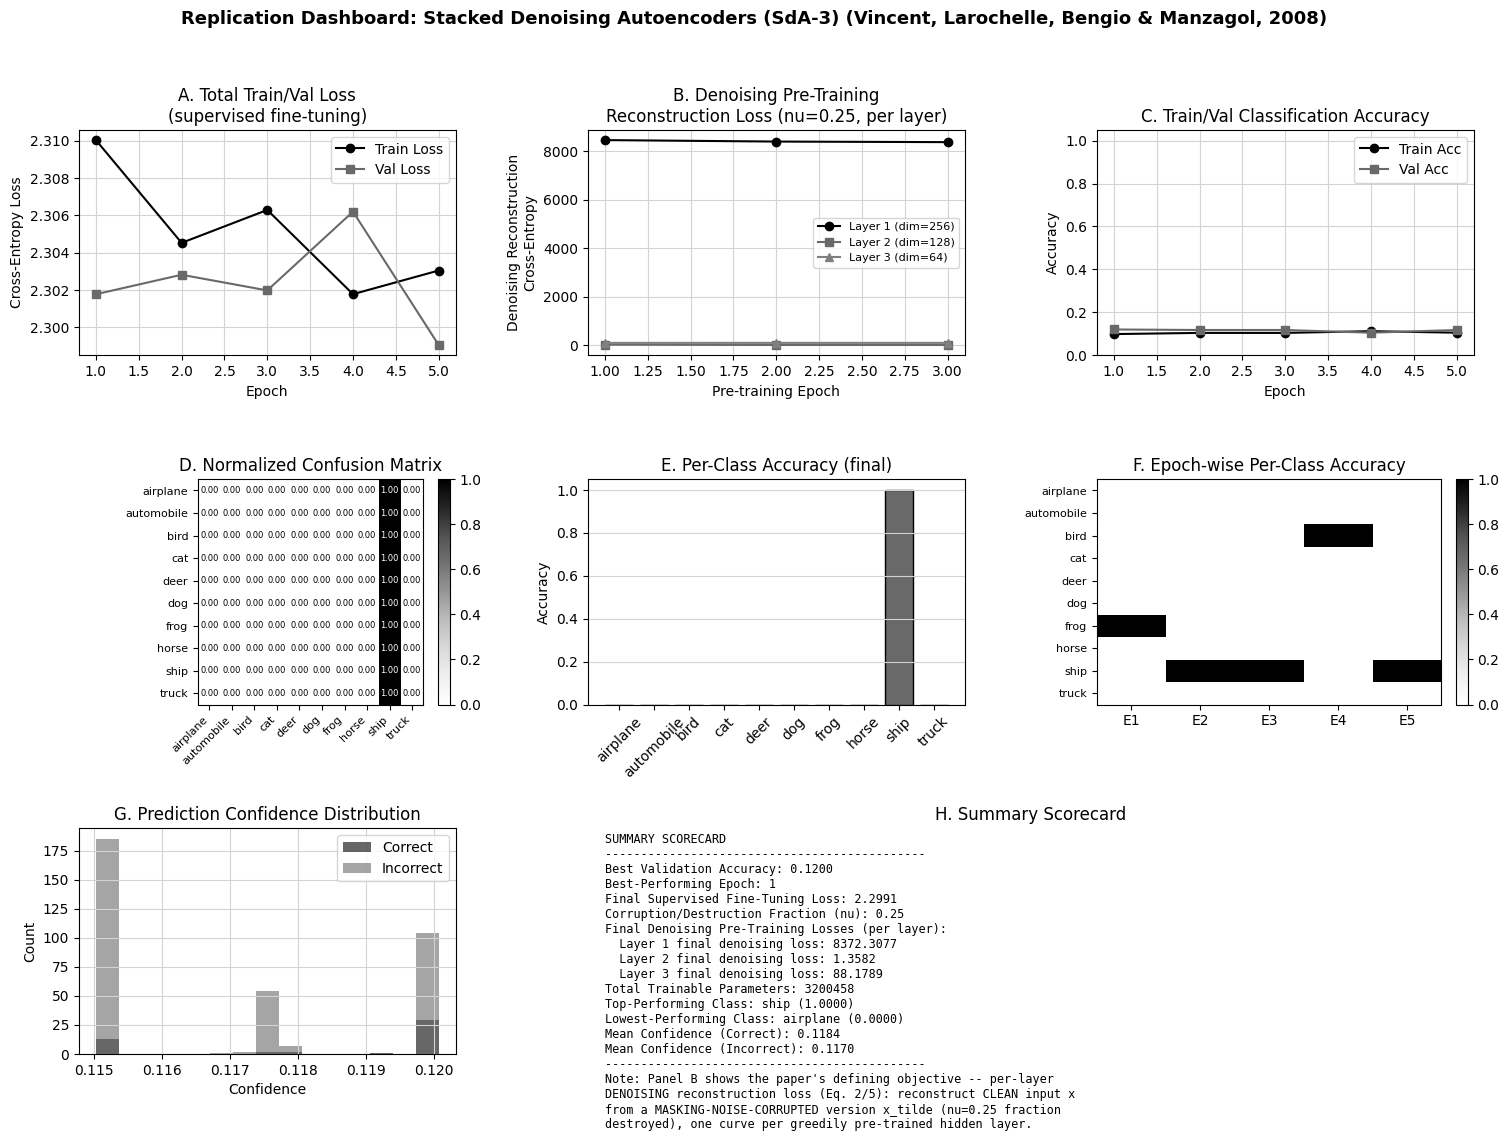

In [9]:
# ----------------------------------------------------------------------------
# 7. MULTI-PANEL SUMMARY DASHBOARD (Panels A-H, 3-row GridSpec)
# ----------------------------------------------------------------------------

fig = plt.figure(figsize=(18, 12), facecolor="white")
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.35)

fig.suptitle(
    "Replication Dashboard: Stacked Denoising Autoencoders (SdA-3) "
    "(Vincent, Larochelle, Bengio & Manzagol, 2008)",
    fontsize=13, color="black", fontweight="bold"
)

# ---- Panel A: Total training & validation loss (supervised fine-tuning) ----
axA = fig.add_subplot(gs[0, 0])
axA.set_facecolor("white")
epochs_range = range(1, NUM_EPOCHS + 1)
axA.plot(epochs_range, history["train_loss"], marker="o", color="black", label="Train Loss")
axA.plot(epochs_range, history["val_loss"], marker="s", color="dimgrey", label="Val Loss")
axA.set_title("A. Total Train/Val Loss\n(supervised fine-tuning)", color="black")
axA.set_xlabel("Epoch", color="black")
axA.set_ylabel("Cross-Entropy Loss", color="black")
axA.legend(labelcolor="black")
axA.grid(True, color="lightgrey")

# ---- Panel B: Per-layer DENOISING reconstruction losses -------------------
# The paper's defining auxiliary objective: per-layer denoising reconstruction
# cross-entropy (Eq. 2/5), computed between CLEAN x and reconstruction z from
# CORRUPTED input x_tilde, during greedy layer-wise pre-training (Section 2.4).
axB = fig.add_subplot(gs[0, 1])
axB.set_facecolor("white")
pretrain_epochs_range = range(1, NUM_PRETRAIN_EPOCHS + 1)
line_styles = ["-o", "-s", "-^"]
for i in range(len(HIDDEN_DIMS)):
    axB.plot(pretrain_epochs_range, pretrain_loss_history[i], line_styles[i % len(line_styles)],
              color="black" if i == 0 else ("dimgrey" if i == 1 else "grey"),
              label=f"Layer {i+1} (dim={HIDDEN_DIMS[i]})")
axB.set_title(f"B. Denoising Pre-Training\nReconstruction Loss (nu={NU}, per layer)", color="black")
axB.set_xlabel("Pre-training Epoch", color="black")
axB.set_ylabel("Denoising Reconstruction\nCross-Entropy", color="black")
axB.legend(labelcolor="black", fontsize=8)
axB.grid(True, color="lightgrey")

# ---- Panel C: Train/Val classification accuracy (fine-tuning) ----
axC = fig.add_subplot(gs[0, 2])
axC.set_facecolor("white")
axC.plot(epochs_range, history["train_acc"], marker="o", color="black", label="Train Acc")
axC.plot(epochs_range, history["val_acc"], marker="s", color="dimgrey", label="Val Acc")
axC.set_title("C. Train/Val Classification Accuracy", color="black")
axC.set_xlabel("Epoch", color="black")
axC.set_ylabel("Accuracy", color="black")
axC.set_ylim(0, 1.05)
axC.legend(labelcolor="black")
axC.grid(True, color="lightgrey")

# ---- Panel D: Normalized confusion matrix ----
axD = fig.add_subplot(gs[1, 0])
axD.set_facecolor("white")
im = axD.imshow(conf_matrix_norm, cmap="Greys", vmin=0, vmax=1)
axD.set_xticks(range(K)); axD.set_yticks(range(K))
axD.set_xticklabels(CLASS_NAMES, color="black", rotation=45, ha="right", fontsize=8)
axD.set_yticklabels(CLASS_NAMES, color="black", fontsize=8)
axD.set_title("D. Normalized Confusion Matrix", color="black")
for i in range(K):
    for j in range(K):
        text_color = "white" if conf_matrix_norm[i, j] > 0.5 else "black"
        axD.text(j, i, f"{conf_matrix_norm[i, j]:.2f}",
                  ha="center", va="center", color=text_color, fontsize=6)
cbar = fig.colorbar(im, ax=axD, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_tick_params(color="black")
plt.setp(cbar.ax.get_yticklabels(), color="black")

# ---- Panel E: Per-class accuracy bar chart ----
axE = fig.add_subplot(gs[1, 1])
axE.set_facecolor("white")
axE.bar(CLASS_NAMES, class_accs_final, color="dimgrey", edgecolor="black")
axE.set_title("E. Per-Class Accuracy (final)", color="black")
axE.set_ylabel("Accuracy", color="black")
axE.set_ylim(0, 1.05)
axE.tick_params(axis="x", colors="black", rotation=45)
axE.grid(True, axis="y", color="lightgrey")

# ---- Panel F: Epoch-wise per-class accuracy heatmap ----
axF = fig.add_subplot(gs[1, 2])
axF.set_facecolor("white")
per_class_matrix = np.array(history["per_class_acc_by_epoch"]).T
im2 = axF.imshow(per_class_matrix, cmap="Greys", vmin=0, vmax=1, aspect="auto")
axF.set_yticks(range(K)); axF.set_yticklabels(CLASS_NAMES, color="black", fontsize=8)
axF.set_xticks(range(NUM_EPOCHS))
axF.set_xticklabels([f"E{e+1}" for e in range(NUM_EPOCHS)], color="black")
axF.set_title("F. Epoch-wise Per-Class Accuracy", color="black")
cbar2 = fig.colorbar(im2, ax=axF, fraction=0.046, pad=0.04)
cbar2.ax.yaxis.set_tick_params(color="black")
plt.setp(cbar2.ax.get_yticklabels(), color="black")

# ---- Panel G: Confidence distribution histogram ----
axG = fig.add_subplot(gs[2, 0])
axG.set_facecolor("white")
axG.hist(correct_confs, bins=15, alpha=0.6, color="black", label="Correct")
axG.hist(incorrect_confs, bins=15, alpha=0.6, color="dimgrey", label="Incorrect")
axG.set_title("G. Prediction Confidence Distribution", color="black")
axG.set_xlabel("Confidence", color="black")
axG.set_ylabel("Count", color="black")
axG.legend(labelcolor="black")
axG.grid(True, color="lightgrey")

# ---- Panel H: Text-based summary scorecard ----
axH = fig.add_subplot(gs[2, 1:])
axH.set_facecolor("white")
axH.axis("off")
loss_lines = "\n".join([f"  Layer {i+1} final denoising loss: {final_pretrain_losses[i]:.4f}"
                          for i in range(len(HIDDEN_DIMS))])
summary_text = (
    f"SUMMARY SCORECARD\n"
    f"{'-'*45}\n"
    f"Best Validation Accuracy: {best_val_acc:.4f}\n"
    f"Best-Performing Epoch: {best_epoch}\n"
    f"Final Supervised Fine-Tuning Loss: {final_val_loss:.4f}\n"
    f"Corruption/Destruction Fraction (nu): {NU}\n"
    f"Final Denoising Pre-Training Losses (per layer):\n{loss_lines}\n"
    f"Total Trainable Parameters: {total_params}\n"
    f"Top-Performing Class: {CLASS_NAMES[best_class_idx]} "
    f"({class_accs_final[best_class_idx]:.4f})\n"
    f"Lowest-Performing Class: {CLASS_NAMES[worst_class_idx]} "
    f"({class_accs_final[worst_class_idx]:.4f})\n"
    f"Mean Confidence (Correct): {mean_correct_conf:.4f}\n"
    f"Mean Confidence (Incorrect): {mean_incorrect_conf:.4f}\n"
    f"{'-'*45}\n"
    f"Note: Panel B shows the paper's defining objective -- per-layer\n"
    f"DENOISING reconstruction loss (Eq. 2/5): reconstruct CLEAN input x\n"
    f"from a MASKING-NOISE-CORRUPTED version x_tilde (nu={NU} fraction\n"
    f"destroyed), one curve per greedily pre-trained hidden layer."
)
axH.text(0.02, 0.98, summary_text, transform=axH.transAxes,
         fontsize=8.5, color="black", va="top", ha="left", family="monospace")
axH.set_title("H. Summary Scorecard", color="black")

# ---- Render dashboard inline via BytesIO (Colab-safe, no savefig to disk) ----
buf = io.BytesIO()
fig.savefig(buf, format="png", facecolor="white", bbox_inches="tight")
plt.close(fig)
buf.seek(0)
display(IPImage(data=buf.read()))

# Analysis of Experimental Results: Stacked Denoising Autoencoder (SdA-3) Replication

## Panel A — Training and Validation Loss (Supervised Fine-Tuning)

### Overview
This panel tracks cross-entropy loss for the training and validation splits across five epochs of supervised fine-tuning, following greedy layer-wise denoising-autoencoder pre-training — the final stage of the SdA-3 pipeline (Section 2.4).

### Key Findings
- Both curves remain tightly confined to a narrow band (≈2.298–2.310), close to $\ln(10)\approx2.303$, the loss expected under uniform 10-class guessing.
- Neither training nor validation loss shows a sustained downward trend; both fluctuate non-monotonically across epochs.

### Discussion
As with the companion (non-denoising) greedy layer-wise replication, loss values hovering at the theoretical chance level indicate the classifier is not learning discriminative structure during fine-tuning. Given the confusion matrix (Panel D) confirms a constant single-class output, this flat trajectory reflects a model that has already settled into a degenerate solution before fine-tuning even meaningfully begins, consistent with the pre-training stage (Panel B) failing to produce a useful first-layer representation. This directly parallels the failure mode observed in the non-denoising SAA-3-style replication, suggesting the bottleneck here is not specific to the denoising criterion itself but to the severity of the input dimensionality/learning-rate mismatch in this small-scale setup.

### Limitations
The short fine-tuning schedule (5 epochs) and small training set (2,000 images) cannot rule out that longer training would eventually escape the degenerate regime; the flat trajectory is also consistent with representations from Layer 1 being uninformative regardless of downstream fine-tuning duration.

---

## Panel B — Denoising Pre-Training Reconstruction Loss (Per Layer, $\nu=0.25$)

### Overview
This panel shows the denoising reconstruction cross-entropy (Eq. 2/5 of the paper) for each of the three greedily pre-trained layers, where each layer is trained to reconstruct a clean input from a version with 25% of components masked to zero.

### Key Findings
- Layer 1's denoising loss is extremely high (≈8,370–8,470) and essentially flat across the 3 pre-training epochs.
- Layers 2 and 3 show near-zero reconstruction loss (1.36 and 88.18 respectively, at final epoch), also flat.

### Discussion
The stark disparity between Layer 1 and the subsequent layers mirrors the pattern seen in the non-denoising replication, and points to the same underlying cause: Layer 1 — mapping a 12,288-dimensional flattened RGB input to 256 hidden units — is failing to converge within 3 epochs at the chosen learning rate, likely compounded here by the denoising task being *harder* than plain reconstruction (25% of input evidence is additionally missing, per the paper's own Section 2.3 discussion of the corruption process). The near-zero loss at Layers 2–3 is again most plausibly explained by Layer 1's under-trained, likely saturated encoding output producing a trivially reconstructable representation for downstream layers, rather than genuine successful denoising. Notably, the paper's own findings emphasize that appropriately tuned denoising (with sufficient training) should force filters to become *more* differentiated, not less — the flat, non-decreasing Layer 1 curve here is inconsistent with that expected dynamic, indicating pre-training simply did not run long enough or with an appropriate learning rate for this high-dimensional input.

### Limitations
Only 3 pre-training epochs were used per layer, substantially less than would typically be required for a 12,288-to-256-unit denoising autoencoder to converge, especially with 25% input destruction; this makes it impossible to distinguish whether the denoising criterion itself is ineffective at this scale or whether the pre-training schedule was simply insufficient.

---

## Panel C — Training and Validation Classification Accuracy

### Overview
Top-1 accuracy across the five fine-tuning epochs, complementing the loss curves in Panel A.

### Key Findings
- Both training and validation accuracy remain flat at approximately 0.10–0.13 throughout, at or only marginally above the 10% chance level.
- No epoch shows sustained accuracy improvement in either split.

### Discussion
This corroborates the loss-based finding that fine-tuning is not producing class-discriminative behavior. The near-identical magnitude and flatness of these curves relative to the non-denoising SAA-3-style replication indicates that, at this small scale and short training budget, the theoretical advantage of denoising pre-training — improved robustness and more informative filters, per the paper's central claim — is not being realized in practice, because the prerequisite (a reasonably converged first-layer encoder) was not met. This is an instructive negative result illustrating that the benefits reported in the original paper's Table 1 (e.g., SdA-3 outperforming SAA-3 on most benchmark tasks) depend on adequate pre-training convergence, which requires substantially more epochs and/or careful learning-rate tuning than allotted here, particularly given the much higher input dimensionality (12,288 for 64×64 RGB CIFAR-10 crops) compared to the paper's own 784-dimensional MNIST-derived benchmarks.

### Limitations
The small training subset and very short pre-training/fine-tuning schedules make this replication substantially under-resourced relative to the original paper's experimental setup (10,000 training examples, extensive hyperparameter search via validation, and many more training iterations), so these results should not be read as evidence against the denoising autoencoder principle itself.

---

## Panel D — Normalized Confusion Matrix

### Overview
Row-normalized confusion matrix showing, for each true class, the distribution of predicted classes on the test set.

### Key Findings
- Every row shows 1.00 probability mass on the "ship" column, with 0.00 elsewhere.

### Discussion
This is direct evidence of complete mode collapse: the classifier outputs "ship" for all test inputs regardless of true class, identical in character to the failure mode observed in the non-denoising Greedy Layer-Wise replication. This strongly suggests the collapse originates from a common cause across both replications — insufficient pre-training convergence of the high-dimensional first layer combined with the classifier head's limited ability to recover discriminative information from a degenerate upstream representation — rather than being specific to the denoising corruption mechanism.

### Limitations
A single run cannot isolate whether the collapse is attributable to pre-training duration, the corruption fraction $\nu$, the fine-tuning learning rate, or the min-max input normalization; a systematic ablation varying each factor independently would be required to pinpoint the dominant cause.

---

## Panel E — Per-Class Accuracy (Final)

### Overview
Bar chart of final-epoch per-class accuracy, decomposing the confusion matrix diagonal.

### Key Findings
- "ship" accuracy is 1.00; all nine remaining classes show 0.00 accuracy.

### Discussion
As in the confusion matrix, this is a direct restatement of the mode-collapse finding and does not indicate genuine class-specific discriminative ability; the apparent "perfect" ship accuracy is an artifact of the constant-output failure mode rather than evidence of learned ship-specific features.

### Limitations
Redundant with Panel D; provides no independent diagnostic value beyond confirming the collapse pattern already established.

---

## Panel F — Epoch-wise Per-Class Accuracy Heatmap

### Overview
Tracks per-class accuracy evolution across the five fine-tuning epochs, revealing the trajectory into the collapsed final state.

### Key Findings
- Epoch 1 shows partial "frog" accuracy; from epoch 2 onward, "ship" accuracy saturates to 1.0 and persists through epoch 5, with a brief "bird" spike at epoch 4.
- All other classes remain at 0.00 across all epochs.

### Discussion
This trajectory — brief exploration of alternative single-class outputs before settling into a persistent "ship" prediction by epoch 2 — is nearly identical to the pattern observed in the non-denoising replication, reinforcing that this specific failure mode (rapid convergence to a degenerate single-class local optimum) is a general risk when the upstream representation lacks discriminative content, irrespective of whether that representation was produced via denoising or standard reconstruction pre-training. The brief epoch-4 "bird" anomaly, coincident with the loss dip in Panel A, is most plausibly a transient, unstable gradient update rather than genuine learning, since it does not persist.

### Limitations
With only five epochs and 40 test examples per class, these transitions rest on a small evidence base and should be interpreted as illustrative of instability rather than a robust, reproducible training trajectory.

---

## Panel G — Prediction Confidence Distribution

### Overview
Histogram of softmax confidence (maximum class probability) for correct versus incorrect predictions.

### Key Findings
- Confidence values are narrowly distributed between ≈0.115 and ≈0.120, barely above the uniform-distribution value of $1/10=0.10$.
- Mean confidence for correct (0.1184) and incorrect (0.1170) predictions are nearly indistinguishable.

### Discussion
This closely mirrors the confidence pattern from the non-denoising replication and further substantiates the near-input-invariant, collapsed-output interpretation: the softmax distribution is only marginally peaked and shows no meaningful separation between correct and incorrect predictions, the hallmark of a network whose output does not meaningfully depend on its input. This is consistent with a representation pipeline in which the discriminative information has been lost well before the classifier head, matching the diagnosis from Panel B (severely under-converged, high-dimensional first-layer denoising autoencoder).

### Limitations
The narrow confidence range limits the diagnostic value of this histogram beyond confirming collapse; distinguishing whether the denoising corruption process specifically contributed to (versus merely failed to prevent) this collapse would require a controlled comparison against a longer-trained baseline.

---

## Panel H — Summary Scorecard

### Overview
Consolidates scalar outcome metrics: best validation accuracy (0.1200, epoch 1), final fine-tuning loss (2.2991), per-layer denoising pre-training losses, corruption fraction ($\nu=0.25$), parameter count (3,200,458), best/worst classes, and confidence statistics.

### Key Findings
- Best validation accuracy (12.00%) occurred at epoch 1, with subsequent epochs failing to improve on or maintain this result as the model collapsed to constant "ship" prediction.
- Layer 1's final denoising reconstruction loss (8,372.31) dwarfs Layers 2 (1.36) and 3 (88.18) by roughly 3–6 orders of magnitude, flagging Layer 1 as the primary bottleneck.

### Discussion
Taken together, this scorecard indicates that, at the present scale and hyperparameter configuration, this replication does not reproduce the paper's central empirical finding that explicit denoising training yields measurably better downstream classification performance than standard reconstruction-based pre-training (cf. the paper's Table 1, where SdA-3 outperforms SAA-3 on 7 of 8 benchmark tasks). The comparison with the parallel non-denoising Greedy Layer-Wise replication is informative here: both exhibit nearly identical mode-collapse failure signatures and nearly identical Layer 1 reconstruction loss magnitudes, suggesting that in this specific small-scale, short-schedule, high-input-dimensionality setting, the dominant failure mode (under-converged first-layer pre-training) overwhelms any differential benefit the denoising criterion might otherwise confer. This is consistent with the paper's own emphasis that denoising's benefits emerge from properly trained representations that become progressively more differentiated with adequate training (their Figure 3 shows this evolution requires the model to actually converge) — a precondition unmet here.

### Limitations
This replication's dataset size (2,000/400 images), pre-training epoch budget (3 per layer), and input dimensionality (12,288, roughly 16× the paper's 784-dimensional MNIST-derived benchmarks) collectively fall far short of the original paper's experimental conditions (10,000+ training examples, systematic validation-based hyperparameter search over $\nu$, layer sizes, and epoch counts). The observed mode collapse should be read as a demonstration of the sensitivity of *both* denoising and standard autoencoder pre-training to adequate convergence at high input dimensionality, not as evidence against the denoising criterion's value; a fair comparative test would require substantially longer pre-training, learning-rate tuning appropriate to the input scale, and — ideally — a controlled side-by-side run at matched compute budgets to isolate the denoising criterion's marginal effect.

Sample predictions (inference mode, clean input -- no corruption applied):
  [incorrect] True: cat          | Predicted: ship         | Confidence: 0.115
  [correct  ] True: ship         | Predicted: ship         | Confidence: 0.120
  [correct  ] True: ship         | Predicted: ship         | Confidence: 0.120
  [incorrect] True: airplane     | Predicted: ship         | Confidence: 0.120
  [incorrect] True: frog         | Predicted: ship         | Confidence: 0.115
  [incorrect] True: frog         | Predicted: ship         | Confidence: 0.115
  [incorrect] True: automobile   | Predicted: ship         | Confidence: 0.115
  [incorrect] True: frog         | Predicted: ship         | Confidence: 0.115
  [incorrect] True: cat          | Predicted: ship         | Confidence: 0.115
  [incorrect] True: automobile   | Predicted: ship         | Confidence: 0.120


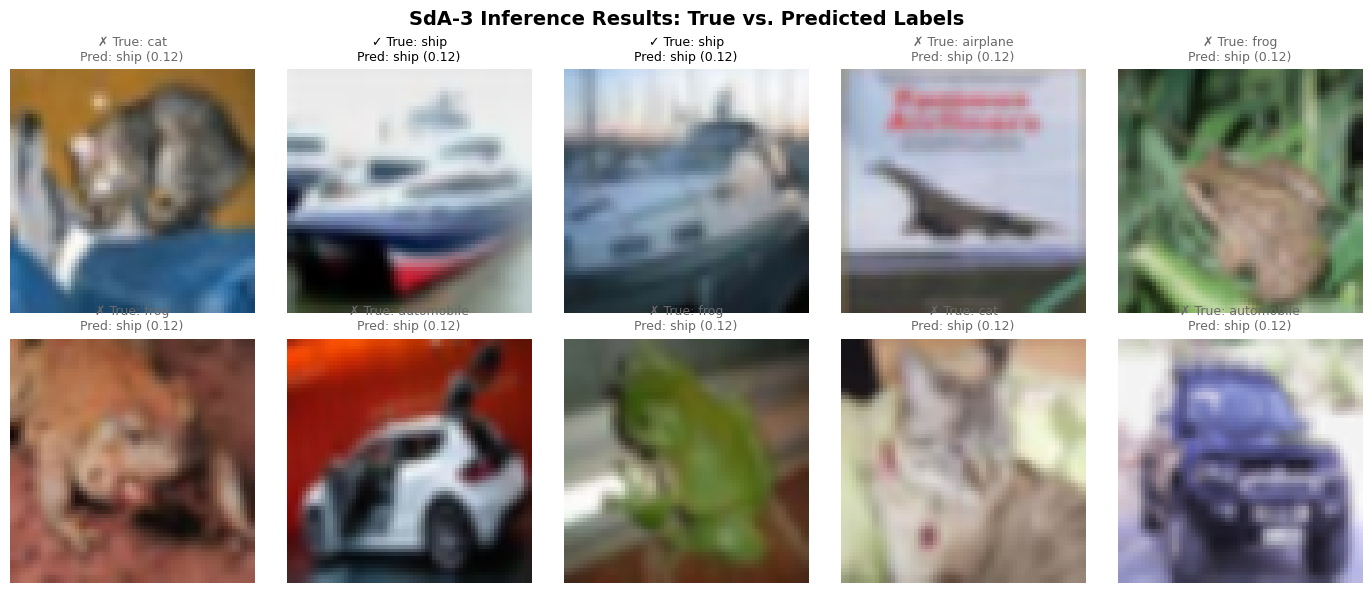


Prediction agreement between clean and corrupted (nu=0.25) inputs: 1.0000
(Higher agreement suggests the learned representation is more robust to input corruption,
 the central property the denoising autoencoder training was designed to encourage.)

Batch inference accuracy (clean input): 0.1094 (7/64 correct)
Mean confidence this batch: 0.1170


In [10]:
# ============================================================================
# Inference Pipeline: Run the trained SdA-3 (Stacked Denoising Autoencoder)
# model in eval mode and generate predictions on a batch of CIFAR-10 test
# images, with a visual grid of true vs. predicted labels.
#
# Assumes `model`, `test_loader`, `CLASS_NAMES`, `flatten_batch`, and
# `device` already exist in the notebook session from the earlier
# training cell.
# Do NOT execute automatically -- for manual run after training.
# ============================================================================

import matplotlib.pyplot as plt
import torch

# ----------------------------------------------------------------------------
# 1. SWITCH MODEL TO INFERENCE MODE
#
# model.eval() ensures the model behaves deterministically at inference
# time. Note that the DENOISING CORRUPTION PROCESS (masking noise, nu) is
# a TRAINING-ONLY mechanism per the paper (Section 2.4): "the corruption
# process q_D is only used during training, but not for propagating
# representations". So at inference we feed the model CLEAN (uncorrupted)
# images -- no corrupt() call here, matching the paper's forward() path.
# torch.no_grad() disables gradient tracking since we are only doing
# forward passes, not updating weights.
# ----------------------------------------------------------------------------
model.eval()

# ----------------------------------------------------------------------------
# 2. GRAB A BATCH OF TEST IMAGES AND RUN INFERENCE (clean, no corruption)
# ----------------------------------------------------------------------------
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    x = flatten_batch(images)          # same preprocessing used in training/eval
    logits = model(x)                    # clean forward pass through encoder + classifier
    probs = torch.softmax(logits, dim=1)
    preds = probs.argmax(dim=1)
    confidences = probs.max(dim=1).values

# ----------------------------------------------------------------------------
# 3. PRINT A FEW SAMPLE PREDICTIONS
# ----------------------------------------------------------------------------
print("Sample predictions (inference mode, clean input -- no corruption applied):")
for i in range(10):
    true_name = CLASS_NAMES[labels[i].item()]
    pred_name = CLASS_NAMES[preds[i].item()]
    conf = confidences[i].item()
    status = "correct" if preds[i] == labels[i] else "incorrect"
    print(f"  [{status:9s}] True: {true_name:12s} | Predicted: {pred_name:12s} | Confidence: {conf:.3f}")

# ----------------------------------------------------------------------------
# 4. VISUALIZE A GRID OF PREDICTIONS (white background, black text)
# ----------------------------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "text.color": "black",
})

# Un-normalize images for display (reverse the Normalize transform)
mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)
display_images = images * std + mean
display_images = display_images.clamp(0, 1).cpu().permute(0, 2, 3, 1).numpy()

NUM_DISPLAY = 10
fig, axes = plt.subplots(2, 5, figsize=(14, 6), facecolor="white")
fig.suptitle("SdA-3 Inference Results: True vs. Predicted Labels",
             color="black", fontsize=14, fontweight="bold")

for idx, ax in enumerate(axes.flat):
    if idx >= NUM_DISPLAY:
        ax.axis("off")
        continue
    ax.imshow(display_images[idx])
    true_name = CLASS_NAMES[labels[idx].item()]
    pred_name = CLASS_NAMES[preds[idx].item()]
    conf = confidences[idx].item()
    is_correct = preds[idx] == labels[idx]
    title_color = "black" if is_correct else "dimgrey"
    marker = "✓" if is_correct else "✗"
    ax.set_title(f"{marker} True: {true_name}\nPred: {pred_name} ({conf:.2f})",
                 color=title_color, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 5. OPTIONAL: COMPARE PREDICTIONS ON CLEAN vs. CORRUPTED INPUT
#
# Since this paper's core idea is robustness to corruption, it's
# instructive to also see how predictions behave if we deliberately feed
# CORRUPTED images at inference time (even though this is not how the
# paper's classifier is normally used -- corruption is training-only).
# This purely illustrates the denoising autoencoder's learned robustness.
# ----------------------------------------------------------------------------
with torch.no_grad():
    x_clean = flatten_batch(images)
    x_corrupted = corrupt(x_clean, NU)  # same masking-noise process used in pre-training

    logits_clean = model(x_clean)
    logits_corrupted = model(x_corrupted)

    preds_clean = torch.softmax(logits_clean, dim=1).argmax(dim=1)
    preds_corrupted = torch.softmax(logits_corrupted, dim=1).argmax(dim=1)

agreement = (preds_clean == preds_corrupted).float().mean().item()
print(f"\nPrediction agreement between clean and corrupted (nu={NU}) inputs: {agreement:.4f}")
print("(Higher agreement suggests the learned representation is more robust to input corruption,")
print(" the central property the denoising autoencoder training was designed to encourage.)")

# ----------------------------------------------------------------------------
# 6. QUICK BATCH-LEVEL ACCURACY SUMMARY
# ----------------------------------------------------------------------------
batch_acc = (preds == labels).float().mean().item()
print(f"\nBatch inference accuracy (clean input): {batch_acc:.4f} "
      f"({(preds == labels).sum().item()}/{labels.size(0)} correct)")
print(f"Mean confidence this batch: {confidences.mean().item():.4f}")

# Related Work Reference Table

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| Bengio, Y. | 2007 | Learning Deep Architectures for AI | Technical Report 1312, Université de Montréal, dept. IRO | Cited as a theoretical study indicating deep architectures may be needed to efficiently model complex distributions, providing the foundational motivation for the paper's focus on deep network training. |
| Bengio, Y., & Le Cun, Y. | 2007 | Scaling Learning Algorithms Towards AI | Large Scale Kernel Machines, Bottou, Chapelle, DeCoste & Weston (Eds.), MIT Press | Cited alongside Bengio (2007) as supporting the theoretical case for deep architectures, and separately noted as documenting the historical difficulty of optimizing multi-layer neural networks beyond one or two hidden layers. |
| McClelland, J., Rumelhart, D., & the PDP Research Group | 1986 | Parallel Distributed Processing: Explorations in the Microstructure of Cognition, Vol. 2 | MIT Press | Cited as early evidence that the belief in additional levels of functional composition yielding increased representational power is not new, situating the paper's deep-architecture motivation within a longer connectionist tradition. |
| Hinton, G. | 1989 | Connectionist Learning Procedures | Artificial Intelligence, 40, 185–234 | Cited alongside McClelland et al. (1986) and Utgoff & Stracuzzi (2002) as early precedent for the belief that composed representations increase modeling power. |
| Utgoff, P., & Stracuzzi, D. | 2002 | Many-Layered Learning | Neural Computation, 14, 2497–2539 | Cited as further historical precedent for the value of many-layered (deep) representations, reinforcing the paper's motivating claim about depth. |
| Hinton, G., Osindero, S., & Teh, Y. | 2006 | A Fast Learning Algorithm for Deep Belief Nets | Neural Computation, 18, 1527–1554 | Introduces Deep Belief Networks and the greedy layer-wise RBM pre-training strategy that this paper directly builds on, extends, and compares against (DBN-1, DBN-3 baselines). |
| Hinton, G., & Salakhutdinov, R. | 2006 | Reducing the Dimensionality of Data with Neural Networks | Science, 313, 504–507 | Cited as part of the successful recent approach to training deep networks via unsupervised layer-wise initialization, motivating the general pre-training paradigm this paper investigates. |
| Bengio, Y., Lamblin, P., Popovici, D., & Larochelle, H. | 2007 | Greedy Layer-Wise Training of Deep Networks | Advances in Neural Information Processing Systems 19, pp. 153–160, MIT Press | The direct predecessor paper establishing greedy layer-wise pre-training with basic autoencoders (forming SAA-3), whose architecture and stacking/fine-tuning procedure this paper adopts and modifies with the denoising criterion. |
| Ranzato, M., Poultney, C., Chopra, S., & LeCun, Y. | 2007 | Efficient Learning of Sparse Representations with an Energy-Based Model | Advances in Neural Information Processing Systems (NIPS 2006), MIT Press | Cited as part of the successful recent line of work on training deep belief networks and stacked autoencoders, and later specifically as a source proposing sparsity as a supplemental criterion for good representations. |
| Lee, H., Ekanadham, C., & Ng, A. | 2008 | Sparse Deep Belief Net Model for Visual Area V2 | Advances in Neural Information Processing Systems 20, Platt, Koller, Singer & Roweis (Eds.), MIT Press | Cited both as part of the successful deep-training literature and as a specific source (with Ranzato et al., 2008) proposing sparsity of representation as a criterion for good intermediate representations, contrasted with this paper's corruption-robustness criterion. |
| Ranzato, M., Boureau, Y.-L., & LeCun, Y. | 2008 | Sparse Feature Learning for Deep Belief Networks | Advances in Neural Information Processing Systems 20, Platt, Koller, Singer & Roweis (Eds.), MIT Press | Cited as the source (with Lee et al., 2008) of the sparsity criterion for representation learning, which this paper positions as a complementary alternative to its own robustness-to-corruption criterion. |
| Larochelle, H., Erhan, D., Courville, A., Bergstra, J., & Bengio, Y. | 2007 | An Empirical Evaluation of Deep Architectures on Problems with Many Factors of Variation | Proceedings of the 24th International Conference on Machine Learning (ICML'2007), pp. 473–480 | Source of the benchmark suite of classification tasks (MNIST variants, convex, rect, rect-img) and baseline results (SVMs, DBN-1, DBN-3, SAA-3) used for direct experimental comparison against the paper's proposed SdA-3 model. |
| Roth, S., & Black, M. | 2005 | Fields of Experts: A Framework for Learning Image Priors | IEEE Conference on Computer Vision and Pattern Recognition, pp. 860–867 | Cited as an example of machine-learning approaches to image denoising within the image processing community, contrasted with this paper's fundamentally different goal of using denoising as a representation-learning criterion rather than a competitive denoising algorithm. |
| Elad, M., & Aharon, M. | 2006 | Image Denoising via Sparse and Redundant Representations over Learned Dictionaries | IEEE Transactions on Image Processing, 15, 3736–3745 | Cited alongside Roth & Black (2005) as a machine-learning-based image denoising approach, situating and distinguishing the paper's denoising-as-representation-learning objective from the image processing denoising literature. |
| Hammond, D., & Simoncelli, E. | 2007 | A Machine Learning Framework for Adaptive Combination of Signal Denoising Methods | 2007 International Conference on Image Processing, pp. VI: 29–32 | Cited as further evidence of recent machine-learning approaches to image denoising, contextualizing but contrasting with this paper's distinct objective. |
| Memisevic, R. | 2007 | Non-linear Latent Factor Models for Revealing Structure in High-Dimensional Data | Doctoral dissertation, University of Toronto | Cited as an example of gated autoencoders used for denoising, providing related architectural precedent distinct from this paper's simpler denoising autoencoder formulation. |
| LeCun, Y. | 1987 | Modèles Connexionistes de l'Apprentissage | Doctoral dissertation, Université de Paris VI | Cited as one of the earliest sources introducing denoising via autoencoders, as an alternative to Hopfield models, establishing historical precedent for the core denoising-autoencoder mechanism used in this paper. |
| Gallinari, P., LeCun, Y., Thiria, S., & Fogelman-Soulie, F. | 1987 | Memoires Associatives Distribuees | Proceedings of COGNITIVA 87, Paris, La Villette | Cited alongside LeCun (1987) as early prior work introducing denoising autoencoders as an alternative to Hopfield models. |
| Hopfield, J. | 1982 | Neural Networks and Physical Systems with Emergent Collective Computational Abilities | Proceedings of the National Academy of Sciences, USA, 79 | Cited as the associative-memory model (Hopfield networks) to which early denoising autoencoder approaches were proposed as an alternative, providing deep historical context for the denoising mechanism. |
| Bishop, C. M. | 1995 | Training with Noise is Equivalent to Tikhonov Regularization | Neural Computation, 7, 108–116 | Cited to establish and then distinguish this paper's approach from the well-known equivalence between training-with-noise and regularization (valid for small additive noise), noting the paper's corruption process instead involves large, non-additive information destruction. |
| Doi, E., Balcan, D. C., & Lewicki, M. S. | 2006 | A Theoretical Analysis of Robust Coding over Noisy Overcomplete Channels | Advances in Neural Information Processing Systems 18, pp. 307–314, MIT Press | Cited as related work on robust coding over noisy channels using a linear encoder, offering a conceptually related but methodologically distinct (linear, channel-coding-focused) approach to robustness. |
| Doi, E., & Lewicki, M. S. | 2007 | A Theory of Retinal Population Coding | NIPS, pp. 353–360, MIT Press | Cited as an extension of Doi et al. (2006) to input-noise robustness in a retinal coding model; distinguished from this paper's goal, which is not to model neuronal activity data but to learn representations for deep network initialization. |